In [11]:
# ==============================================================================
# 1. SETUP & LIBRARIES
# ==============================================================================
# Why: นำเข้าเครื่องมือที่จำเป็นสำหรับการประมวลผลข้อมูลและการสร้างภาพสถิติ
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Optimization: ปิดการแจ้งเตือนที่ไม่จำเป็นและตั้งค่ากราฟให้สวยงาม
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ==============================================================================
# 2. DATA LOADING (Optimized)
# ==============================================================================
# Why: โหลดข้อมูลจาก CSV โดยระบุ dtypes เพื่อประหยัด Memory (Big Data Optimization)
def load_and_profile(file_path):
    # กำหนด DataType เพื่อประสิทธิภาพ (ระบุเฉพาะคอลัมน์สำคัญ)
    dtype_spec = {
        'interview__key': 'category',
        'shocks__id': 'int16',
        'v31105a': 'float32'  # ปีที่เกิดเหตุ
    }
    
    df = pd.read_csv(file_path, dtype=dtype_spec)
    
    # Initial Data Profiling
    print(f"--- Data Profile: {file_path} ---")
    print(f"Total Rows: {len(df)}")
    print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    return df



In [12]:
def load_and_convert(dta_file, output_csv):
    """Loads Stata file, preserves labels, and saves to CSV."""
    # Read as iterator to extract labels if needed
    with pd.io.stata.StataReader(dta_file) as reader:
        var_labels = reader.variable_labels()
    
    # Read the actual data
    df = pd.read_stata(dta_file)
    
    # Print memory optimization info
    print(f"Loaded {dta_file} | Shape: {df.shape} | Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    # Save CSV
    df.to_csv(output_csv, index=False)
    return df, var_labels

In [13]:
# Perform conversion
shocks, shocks_labels = load_and_convert('shocks.dta', 'shocks.csv')

print("Data loaded successfully.")

print(shocks_labels)

Loaded shocks.dta | Shape: (2091, 80) | Memory: 1.57 MB
Data loaded successfully.
{'interview__key': 'Interview key (identifier in XX-XX-XX-XX format)', 'interview__id': 'Unique 32-character long identifier of the interview', 'shocks__id': 'Id in "shocks"', 'shocks_detail__id': 'Id in shocks_detail', 'v31102d': 'Did this shock happen to all HH members?', 'v31102a__0': '', 'v31102a__1': '', 'v31102a__2': '', 'v31102a__3': '', 'v31103': 'When did the event occur? - Year', 'v31103a': 'When did the event occur? - Month', 'v31103b': 'When did the event occur? - Time in month', 'v31104': 'Estimated severity of the event on your household?', 'v31105a': 'Estimated total loss of income due to the event', 'v31105b': 'Estimated total extra expenditure due to the event', 'v31106a': 'Estimated loss of assets due to the event', 'v31107': 'Aside from your HH who else was affected by the event?', 'v31108a__1': 'category of coping activity:Economics / Social', 'v31108a__2': 'category of coping activity

Data loaded with 2091 rows and 80 columns.
Cleaning step complete: 'none' converted to 0, and Stata missing codes handled.


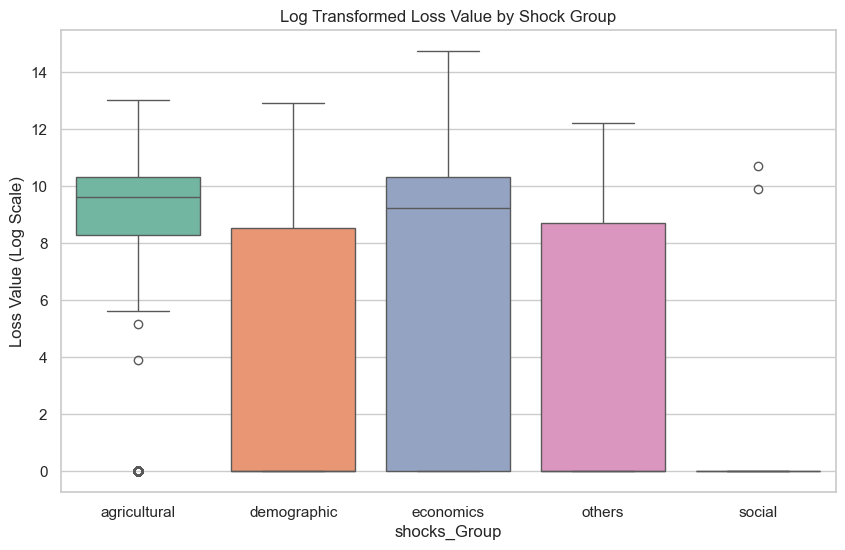

Final file 'shocks_final_processed.csv' is ready for Panel Data analysis.


In [14]:
# ==============================================================================
# 2. DATA LOADING
# ==============================================================================
# โหลดข้อมูล shocks.csv
# df = pd.read_csv('shocks.csv')
print(f"Data loaded with {df.shape[0]} rows and {df.shape[1]} columns.")

# ==============================================================================
# 3. DATA CLEANING (Handling 'none' and Missing Values)
# ==============================================================================
def advanced_cleaning(df):
    """
    ฟังก์ชันทำความสะอาดข้อมูลขั้นสูง:
    1. จัดการคำว่า 'none' ให้เป็น 0
    2. จัดการรหัส -9, -99 ให้เป็น NaN
    3. แปลงคอลัมน์ที่ควรเป็นตัวเลขให้ถูกต้อง
    """
    # รายชื่อคอลัมน์ที่มักจะเจอปัญหา 'none' (อ้างอิงจาก Questionnaire Section 3)
    # v31105a: Total value of loss, v31105b: Crop loss, v31106a: Asset loss
    numeric_target_cols = ['v31105a', 'v31105b', 'v31106a', 'shockmoneyloss']
    
    for col in numeric_target_cols:
        if col in df.columns:
            # เปลี่ยน 'none' หรือช่องว่างให้เป็น 0 ก่อนแปลงเป็นตัวเลข
            df[col] = df[col].astype(str).str.replace('none', '0', case=False).str.strip()
            # แปลงเป็นตัวเลข ถ้าแปลงไม่ได้ (เช่น ตัวอักษรอื่นๆ) ให้เป็น NaN (coerce)
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    # จัดการรหัส Stata Missing (-9, -99) ในทุกคอลัมน์ที่เป็นตัวเลข
    df = df.replace([-9, -99, -9.0, -99.0], np.nan)
    
    print("Cleaning step complete: 'none' converted to 0, and Stata missing codes handled.")
    return df

df_cleaned = advanced_cleaning(shocks)

# ==============================================================================
# 4. SHOCK TRANSFORMATION
# ==============================================================================
# Mapping รหัส ID เป็นชื่อกลุ่ม (Logic เดิมจากแบบสอบถาม)
shock_mapping = {
    1: 'Illness of household member', 2: 'Death of household member',
    3: 'Household member left the household', 5: 'Had to spent money because of ceremony',
    6: 'House damage', 8: 'Conflict with neighbours in the village',
    10: 'Flooding of agricultural land', 11: 'Drought',
    18: 'Collapse of business', 21: 'Strong decrease of prices for Output',
    22: 'Strong increase of prices for Input', 24: 'Accident',
    46: 'being cheated at work/business', 55: 'Storm',
    62: 'Job loss', 63: 'Pests and Livestock diseases',
    70: 'victim of crime (theft, robbery, etc.)', 77: 'Flooding on the house/homestead',
    90: 'Other, specify'
}

def get_group(desc):
    if desc in ['Drought', 'Flooding of agricultural land', 'Pests and Livestock diseases', 'Storm']:
        return "agricultural"
    elif desc in ['Illness of household member', 'Death of household member', 'Accident', 'Household member left the household']:
        return "demographic"
    elif desc in ['House damage', 'Job loss', 'Flooding on the house/homestead', 'being cheated at work/business',
                  'Collapse of business', 'Strong increase of prices for Input', 'Strong decrease of prices for Output',
                  'Had to spent money because of ceremony']:
        return "economics"
    elif desc in ['Conflict with neighbours in the village', 'victim of crime (theft, robbery, etc.)']:
        return "social"
    return "others"

df_cleaned['shock_description'] = df_cleaned['shocks__id'].map(shock_mapping)
df_cleaned['shocks_Group'] = df_cleaned['shock_description'].apply(get_group)

# สร้าง Log Value สำหรับการวิเคราะห์มูลค่าความเสียหาย (v31105a คือตัวเลขความเสียหายรวม)
df_cleaned['loss_log'] = np.log1p(df_cleaned['v31105a'])

# ==============================================================================
# 5. VISUALIZATION
# ==============================================================================
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_cleaned, x='shocks_Group', y='loss_log', palette='Set2')
plt.title('Log Transformed Loss Value by Shock Group')
plt.ylabel('Loss Value (Log Scale)')
plt.show()

# ==============================================================================
# 6. EXPORT
# ==============================================================================
df_cleaned.to_csv('shocks_final_processed.csv', index=False)
print("Final file 'shocks_final_processed.csv' is ready for Panel Data analysis.")